## Imports and paths

In [1]:
from pathlib import Path
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from catboost import CatBoostRegressor

In [2]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

RANDOM_STATE = 42
TEST_SIZE = 0.2

PROJECT_DIR = Path.cwd().parent

DATA_PATH = PROJECT_DIR / "data" / "processed" / "real_estate_clean.csv"

MODELS_DIR = PROJECT_DIR / "models"
REPORTS_DIR = PROJECT_DIR / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

DATA_PATH

WindowsPath('c:/Users/mikri/OneDrive/Desktop/real-estate-price-advisor/data/processed/real_estate_clean.csv')

## Load cleaned dataset

In [3]:
df = pd.read_csv(
    DATA_PATH,
    parse_dates=["published_at"],
    low_memory=False,
)

df.head()

,price,date,time,geo_lat,geo_lon,region,building_type,floor,floors,rooms,area,kitchen_area,object_type,published_at,publication_year,publication_quarter,publication_month
0,6050000,2018-02-19,20:00:21,59.81,30.38,2661,1,8,10,3,82.60,10.80,1,2018-02-19 20:00:21,2018,1,2
1,8650000,2018-02-27,12:04:54,55.68,37.30,81,3,5,24,2,69.10,12.00,1,2018-02-27 12:04:54,2018,1,2
2,4000000,2018-02-28,15:44:00,56.30,44.06,2871,1,5,9,3,66.00,10.00,1,2018-02-28 15:44:00,2018,1,2
3,1850000,2018-03-01,11:24:52,45.00,39.07,2843,4,12,16,2,38.00,5.00,11,2018-03-01 11:24:52,2018,1,3
4,5450000,2018-03-01,17:42:43,55.92,37.98,81,3,13,14,2,60.00,10.00,1,2018-03-01 17:42:43,2018,1,3


In [4]:
df.shape

(5470541, 17)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5470541 entries, 0 to 5470540
Data columns (total 17 columns):
 #   Column               Dtype         
---  ------               -----         
 0   price                int64         
 1   date                 str           
 2   time                 str           
 3   geo_lat              float64       
 4   geo_lon              float64       
 5   region               int64         
 6   building_type        int64         
 7   floor                int64         
 8   floors               int64         
 9   rooms                int64         
 10  area                 float64       
 11  kitchen_area         float64       
 12  object_type          int64         
 13  published_at         datetime64[us]
 14  publication_year     int64         
 15  publication_quarter  int64         
 16  publication_month    int64         
dtypes: datetime64[us](1), float64(4), int64(10), str(2)
memory usage: 709.5 MB


In [6]:
target = 'price'

df[target].describe()

count       5,470,541.00
mean        4,537,035.41
std        15,519,251.07
min                 1.00
25%         1,950,000.00
50%         2,990,000.00
75%         4,807,840.00
max     2,147,483,647.00
Name: price, dtype: float64

## Feature engineering

In [7]:
df_model = df.copy()

df_model["publication_year"] = df_model["published_at"].dt.year
df_model["publication_month"] = df_model["published_at"].dt.month
df_model["publication_quarter"] = df_model["published_at"].dt.quarter

df_model["floor_ratio"] = df_model["floor"] / df_model["floors"]
df_model["is_first_floor"] = (df_model["floor"] == 1).astype(int)
df_model["is_last_floor"] = (df_model["floor"] == df_model["floors"]).astype(int)

df_model["is_studio"] = (df_model["rooms"] == -1).astype(int)
df_model["rooms_count"] = df_model["rooms"].replace(-1, 0)

df_model["kitchen_area_missing"] = df_model["kitchen_area"].isna().astype(int)

df_model.head()

,price,date,time,geo_lat,geo_lon,region,building_type,floor,floors,rooms,area,kitchen_area,object_type,published_at,publication_year,publication_quarter,publication_month,floor_ratio,is_first_floor,is_last_floor,is_studio,rooms_count,kitchen_area_missing
0,6050000,2018-02-19,20:00:21,59.81,30.38,2661,1,8,10,3,82.60,10.80,1,2018-02-19 20:00:21,2018,1,2,0.80,0,0,0,3,0
1,8650000,2018-02-27,12:04:54,55.68,37.30,81,3,5,24,2,69.10,12.00,1,2018-02-27 12:04:54,2018,1,2,0.21,0,0,0,2,0
2,4000000,2018-02-28,15:44:00,56.30,44.06,2871,1,5,9,3,66.00,10.00,1,2018-02-28 15:44:00,2018,1,2,0.56,0,0,0,3,0
3,1850000,2018-03-01,11:24:52,45.00,39.07,2843,4,12,16,2,38.00,5.00,11,2018-03-01 11:24:52,2018,1,3,0.75,0,0,0,2,0
4,5450000,2018-03-01,17:42:43,55.92,37.98,81,3,13,14,2,60.00,10.00,1,2018-03-01 17:42:43,2018,1,3,0.93,0,0,0,2,0


## Outlier filtering

In [8]:
df_model["price_per_m2"] = df_model["price"] / df_model["area"]

outlier_check_columns = [
    "price",
    "area",
    "price_per_m2",
    "rooms_count",
    "floor",
    "floors",
]

df_model[outlier_check_columns].quantile([
    0.001,
    0.005,
    0.01,
    0.05,
    0.5,
    0.95,
    0.99,
    0.995,
    0.999,
])

,price,area,price_per_m2,rooms_count,floor,floors
0.00,"210,000.00",10.20,"3,740.05",0.00,1.00,1.00
0.01,"595,000.00",17.00,"13,513.51",0.00,1.00,2.00
0.01,"750,000.00",19.80,"18,072.29",0.00,1.00,2.00
0.05,"1,150,000.00",29.00,"27,691.96",0.00,1.00,3.00
0.50,"2,990,000.00",48.02,"61,000.00",2.00,5.00,10.00
0.95,"11,386,935.00",93.00,"191,891.89",3.00,16.00,25.00
0.99,"24,050,000.00",138.10,"303,278.69",4.00,23.00,27.00
0.99,"34,999,999.00",165.00,"369,565.22",4.00,24.00,32.00
1.00,"86,640,284.60",294.00,"673,913.04",5.00,29.00,36.00


In [9]:
rows_before_outlier_filtering = df_model.shape[0]

MIN_PRICE = 300_000
MAX_PRICE = 300_000_000

MIN_AREA = 8
MAX_AREA = 1000

MIN_PRICE_PER_M2 = 10_000
MAX_PRICE_PER_M2 = 2_000_000

MAX_ROOMS = 10

valid_market_mask = (
    df_model["price"].between(MIN_PRICE, MAX_PRICE)
    & df_model["area"].between(MIN_AREA, MAX_AREA)
    & df_model["price_per_m2"].between(MIN_PRICE_PER_M2, MAX_PRICE_PER_M2)
    & df_model["rooms_count"].between(0, MAX_ROOMS)
)

print("Rows before outlier filtering:", rows_before_outlier_filtering)
print("Rows to remove:", (~valid_market_mask).sum())
print(
    "Removed percent:",
    round((~valid_market_mask).mean() * 100, 2)
)

Rows before outlier filtering: 5470541
Rows to remove: 20764
Removed percent: 0.38


In [10]:
df_model.loc[
    ~valid_market_mask,
    [
        "price",
        "area",
        "price_per_m2",
        "rooms_count",
        "region",
        "building_type",
        "object_type",
        "published_at",
    ]
].sort_values("price").head(20)

,price,area,price_per_m2,rooms_count,region,building_type,object_type,published_at
1761154,1,54.00,0.02,2,10160,3,1,2019-05-09 06:50:18
1633551,1,37.30,0.03,2,2922,1,1,2019-04-18 10:01:36
278672,1,46.00,0.02,2,4417,1,1,2018-10-16 08:45:44
4870801,1,34.20,0.03,1,3,1,1,2020-12-20 18:45:57
1553162,1,90.00,0.01,4,5241,5,1,2019-04-07 19:24:11
4420238,1,546.00,0.00,0,3,3,1,2020-09-22 06:01:52
4425921,1,15.00,0.07,3,9648,4,1,2020-09-22 23:24:51
3386877,1,56.00,0.02,2,81,1,1,2020-03-03 12:17:27
1966671,1,52.00,0.02,2,9648,1,1,2019-06-10 15:59:19
1376190,1,120.00,0.01,3,2843,3,1,2019-03-16 02:47:55


In [11]:
df_model.loc[
    ~valid_market_mask,
    [
        "price",
        "area",
        "price_per_m2",
        "rooms_count",
        "region",
        "building_type",
        "object_type",
        "published_at",
    ]
].sort_values("price", ascending=False).head(20)

,price,area,price_per_m2,rooms_count,region,building_type,object_type,published_at
1140494,2147483647,50.00,"42,949,672.94",2,81,3,1,2019-02-13 18:13:38
3595633,2147483647,44.20,"48,585,602.87",1,3991,0,11,2020-04-14 17:48:35
1051674,2089477704,95.86,"21,797,180.30",3,2843,2,11,2019-02-01 08:52:19
1394798,2089477704,95.86,"21,797,180.30",3,2843,2,11,2019-03-19 10:29:50
1638931,2083290000,63.00,"33,068,095.24",2,9654,4,1,2019-04-19 06:37:23
1643689,2083290000,63.00,"33,068,095.24",2,9654,4,1,2019-04-20 03:23:16
1623502,2083290000,63.00,"33,068,095.24",2,9654,4,1,2019-04-17 02:29:00
1615892,2083290000,63.00,"33,068,095.24",2,9654,4,1,2019-04-16 06:15:59
1632234,2083290000,63.00,"33,068,095.24",2,9654,4,1,2019-04-18 06:24:09
1459773,2083290000,63.00,"33,068,095.24",2,9654,4,1,2019-03-27 09:27:15


In [12]:
df_model = df_model.loc[valid_market_mask].copy()

rows_after_outlier_filtering = df_model.shape[0]

print("Rows before outlier filtering:", rows_before_outlier_filtering)
print("Rows after outlier filtering:", rows_after_outlier_filtering)
print("Removed rows:", rows_before_outlier_filtering - rows_after_outlier_filtering)
print(
    "Removed percent:",
    round(
        (rows_before_outlier_filtering - rows_after_outlier_filtering)
        / rows_before_outlier_filtering
        * 100,
        2
    )
)

Rows before outlier filtering: 5470541
Rows after outlier filtering: 5449777
Removed rows: 20764
Removed percent: 0.38


In [13]:
df_model[["price", "area", "price_per_m2", "rooms_count",]].describe()

,price,area,price_per_m2,rooms_count
count,"5,449,777.00","5,449,777.00","5,449,777.00","5,449,777.00"
mean,"4,385,966.05",53.68,"78,310.50",1.78
std,"6,222,767.18",24.26,"60,536.73",0.96
min,"300,000.00",8.00,"10,000.00",0.00
25%,"1,950,000.00",38.10,"43,055.56",1.00
50%,"3,000,000.00",48.02,"61,061.95",2.00
75%,"4,837,000.00",63.13,"91,549.30",2.00
max,"300,000,000.00","1,000.00","2,000,000.00",10.00


In [14]:
df_model[["price", "area", "price_per_m2", "rooms_count",]].quantile([0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999,])

,price,area,price_per_m2,rooms_count
0.00,"470,000.00",13.00,"11,764.71",0.00
0.01,"800,000.00",20.00,"19,819.82",0.00
0.05,"1,160,000.00",29.00,"27,953.04",0.00
0.50,"3,000,000.00",48.02,"61,061.95",2.00
0.95,"11,386,789.40",93.00,"190,966.53",3.00
0.99,"24,000,000.00",137.00,"298,000.00",4.00
1.00,"79,500,000.00",250.00,"595,383.75",5.00


## Select features

In [15]:
numeric_features = [
    "area",
    "kitchen_area",
    "rooms_count",
    "floor",
    "floors",
    "floor_ratio",
    "is_first_floor",
    "is_last_floor",
    "is_studio",
    "kitchen_area_missing",
    "geo_lat",
    "geo_lon",
    "publication_year",
    "publication_month",
    "publication_quarter",
]

categorical_features = [
    "region",
    "building_type",
    "object_type",
]

features = numeric_features + categorical_features

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("All features:", features)

Numeric features: ['area', 'kitchen_area', 'rooms_count', 'floor', 'floors', 'floor_ratio', 'is_first_floor', 'is_last_floor', 'is_studio', 'kitchen_area_missing', 'geo_lat', 'geo_lon', 'publication_year', 'publication_month', 'publication_quarter']
Categorical features: ['region', 'building_type', 'object_type']
All features: ['area', 'kitchen_area', 'rooms_count', 'floor', 'floors', 'floor_ratio', 'is_first_floor', 'is_last_floor', 'is_studio', 'kitchen_area_missing', 'geo_lat', 'geo_lon', 'publication_year', 'publication_month', 'publication_quarter', 'region', 'building_type', 'object_type']


## Train/test split

In [16]:
USE_TIME_SPLIT = True

can_use_time_split = (
    "published_at" in df_model.columns
    and df_model["published_at"].notna().sum() > 0
)

if USE_TIME_SPLIT and can_use_time_split:
    rows_before_time_filter = df_model.shape[0]
    
    df_model = (
        df_model
        .dropna(subset=["published_at"])
        .sort_values("published_at")
        .reset_index(drop=True)
    )
    
    split_index = int(df_model.shape[0] * (1 - TEST_SIZE))
    
    train_df = df_model.iloc[:split_index].copy()
    test_df = df_model.iloc[split_index:].copy()
    
    split_type = "time_based"
    
    print("Time-based split was used.")
    print("Rows before time filter:", rows_before_time_filter)
    print("Rows after time filter:", df_model.shape[0])
else:
    train_df, test_df = train_test_split(
        df_model,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )
    
    split_type = "random"
    
    print("Random train/test split was used.")

print("Split type:", split_type)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Time-based split was used.
Rows before time filter: 5449777
Rows after time filter: 5449777
Split type: time_based
Train shape: (4359821, 24)
Test shape: (1089956, 24)


In [17]:
X_train = train_df[features]
X_test = test_df[features]

y_train = train_df[target]
y_test = test_df[target]

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4359821, 18)
X_test: (1089956, 18)
y_train: (4359821,)
y_test: (1089956,)


## Metrics functions

In [18]:
def inverse_log_target(y_log):
    return np.clip(np.expm1(y_log), 1, None)


def median_absolute_percentage_error(y_true, y_pred):
    absolute_percentage_error = np.abs((y_true - y_pred) / y_true) * 100
    return np.median(absolute_percentage_error)


def weighted_absolute_percentage_error(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100


def calculate_regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    mdape = median_absolute_percentage_error(y_true, y_pred)
    wape = weighted_absolute_percentage_error(y_true, y_pred)
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape,
        "MdAPE": mdape,
        "WAPE": wape,
    }


def evaluate_model(model_name, y_true, y_pred):
    metrics = calculate_regression_metrics(y_true, y_pred)
    metrics["model"] = model_name
    return metrics

## Model 1: DummyRegressor

In [19]:
dummy_model = DummyRegressor(strategy="median")

dummy_model.fit(X_train, y_train_log)

dummy_pred_log = dummy_model.predict(X_test)
dummy_pred = inverse_log_target(dummy_pred_log)

dummy_metrics = evaluate_model(
    model_name="dummy_median",
    y_true=y_test,
    y_pred=dummy_pred
)

dummy_metrics

{'MAE': 3400781.3520729276,
 'RMSE': np.float64(8441421.288495835),
 'R2': -0.13673842779157197,
 'MAPE': 48.06139122780992,
 'MdAPE': np.float64(42.268041237113366),
 'WAPE': np.float64(59.37401139466102),
 'model': 'dummy_median'}

## Model 2: Ridge with preprocessing pipeline

In [20]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0)),
])

In [21]:
ridge_model.fit(X_train, y_train_log)

ridge_pred_log = ridge_model.predict(X_test)
ridge_pred = inverse_log_target(ridge_pred_log)

ridge_metrics = evaluate_model(
    model_name="ridge",
    y_true=y_test,
    y_pred=ridge_pred
)

ridge_metrics

{'MAE': 4656773.99743429,
 'RMSE': np.float64(1361065873.824925),
 'R2': -29551.054645298675,
 'MAPE': 33.399115274320906,
 'MdAPE': np.float64(20.743025013459103),
 'WAPE': np.float64(81.3023019599572),
 'model': 'ridge'}

## Model 3: CatBoostRegressor

In [22]:
catboost_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    random_seed=RANDOM_STATE,
    verbose=100,
)

In [23]:
catboost_model.fit(
    X_train,
    y_train_log,
    cat_features=categorical_features,
)

catboost_pred_log = catboost_model.predict(X_test)
catboost_pred = inverse_log_target(catboost_pred_log)

catboost_metrics = evaluate_model(
    model_name="catboost",
    y_true=y_test,
    y_pred=catboost_pred
)

catboost_metrics

0:	learn: 0.6683399	total: 789ms	remaining: 6m 33s
100:	learn: 0.2645283	total: 53.7s	remaining: 3m 32s
200:	learn: 0.2424193	total: 1m 47s	remaining: 2m 39s
300:	learn: 0.2316254	total: 2m 41s	remaining: 1m 47s
400:	learn: 0.2246443	total: 3m 36s	remaining: 53.4s
499:	learn: 0.2192982	total: 4m 32s	remaining: 0us


{'MAE': 1292953.708612955,
 'RMSE': np.float64(3847273.595897979),
 'R2': 0.7638784991755966,
 'MAPE': 19.951840184110186,
 'MdAPE': np.float64(16.748095591983652),
 'WAPE': np.float64(22.573591266360417),
 'model': 'catboost'}

## Compare models

In [24]:
metrics_table = pd.DataFrame([
    dummy_metrics,
    ridge_metrics,
    catboost_metrics,
])

metrics_table = metrics_table[
    ["model", "MAE", "RMSE", "R2", "MAPE", "MdAPE", "WAPE"]
].sort_values("MAE")

metrics_table

,model,MAE,RMSE,R2,MAPE,MdAPE,WAPE
2,catboost,"1,292,953.71","3,847,273.60",0.76,19.95,16.75,22.57
0,dummy_median,"3,400,781.35","8,441,421.29",-0.14,48.06,42.27,59.37
1,ridge,"4,656,774.00","1,361,065,873.82","-29,551.05",33.40,20.74,81.30


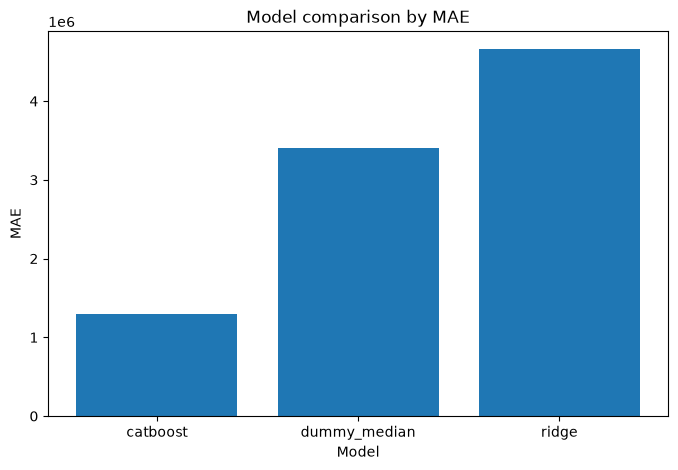

In [25]:
plt.figure(figsize=(8, 5))
plt.bar(metrics_table["model"], metrics_table["MAE"])
plt.title("Model comparison by MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.show()

In [41]:
MODEL_COMPARISON_PATH = FIGURES_DIR / "model_comparison_mae.png"

plt.savefig(MODEL_COMPARISON_PATH, dpi=300, bbox_inches="tight")

print("Saved figure:", MODEL_COMPARISON_PATH)

Saved figure: c:\Users\mikri\OneDrive\Desktop\real-estate-price-advisor\reports\figures\model_comparison_mae.png


<Figure size 640x480 with 0 Axes>

## Select best model

In [26]:
models = {
    "dummy_median": dummy_model,
    "ridge": ridge_model,
    "catboost": catboost_model,
}

predictions = {
    "dummy_median": dummy_pred,
    "ridge": ridge_pred,
    "catboost": catboost_pred,
}

best_model_name = metrics_table.iloc[0]["model"]
best_model = models[best_model_name]
best_pred = predictions[best_model_name]

print("Best model:", best_model_name)

Best model: catboost


## Prediction quality check

In [27]:
prediction_check = pd.DataFrame({
    "actual_price": y_test.values,
    "predicted_price": best_pred,
})

prediction_check["error"] = prediction_check["actual_price"] - prediction_check["predicted_price"]
prediction_check["absolute_error"] = prediction_check["error"].abs()
prediction_check["absolute_percentage_error"] = (
    prediction_check["absolute_error"] / prediction_check["actual_price"] * 100
)

prediction_check.head()

,actual_price,predicted_price,error,absolute_error,absolute_percentage_error
0,1630000,"1,794,824.63","-164,824.63","164,824.63",10.11
1,6000000,"6,283,589.31","-283,589.31","283,589.31",4.73
2,3550000,"3,311,779.09","238,220.91","238,220.91",6.71
3,4700000,"6,902,942.69","-2,202,942.69","2,202,942.69",46.87
4,1370000,"1,404,834.03","-34,834.03","34,834.03",2.54


In [28]:
prediction_check[[
    "actual_price",
    "predicted_price",
    "absolute_error",
    "absolute_percentage_error",
]].describe()

,actual_price,predicted_price,absolute_error,absolute_percentage_error
count,"1,089,956.00","1,089,956.00","1,089,956.00","1,089,956.00"
mean,"5,727,727.12","4,844,389.26","1,292,953.71",19.95
std,"7,917,453.18","5,879,247.05","3,623,506.16",24.03
min,"300,000.00","416,752.49",0.22,0.00
25%,"2,599,000.00","2,312,339.68","261,399.13",8.16
50%,"3,859,450.00","3,342,352.35","614,042.16",16.75
75%,"6,400,000.00","5,336,444.90","1,297,694.92",27.04
max,"300,000,000.00","212,699,841.25","239,068,541.56","4,512.79"


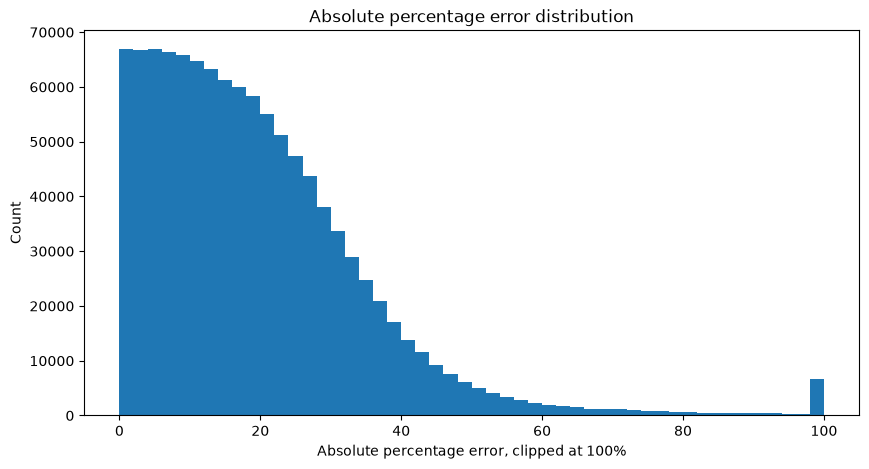

In [29]:
plt.figure(figsize=(10, 5))
plt.hist(prediction_check["absolute_percentage_error"].clip(upper=100), bins=50)
plt.title("Absolute percentage error distribution")
plt.xlabel("Absolute percentage error, clipped at 100%")
plt.ylabel("Count")
plt.show()

## Actual vs predicted plot

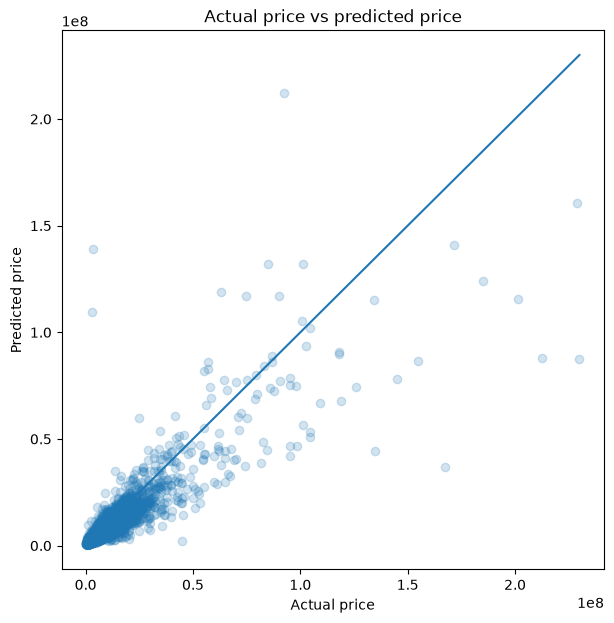

In [30]:
plot_sample_size = min(20_000, prediction_check.shape[0])
plot_sample = prediction_check.sample(plot_sample_size, random_state=RANDOM_STATE)

plt.figure(figsize=(7, 7))
plt.scatter(
    plot_sample["actual_price"],
    plot_sample["predicted_price"],
    alpha=0.2
)

min_price = min(plot_sample["actual_price"].min(), plot_sample["predicted_price"].min())
max_price = max(plot_sample["actual_price"].max(), plot_sample["predicted_price"].max())

plt.plot([min_price, max_price], [min_price, max_price])
plt.title("Actual price vs predicted price")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.show()

In [42]:
ACTUAL_VS_PREDICTED_PATH = FIGURES_DIR / "actual_vs_predicted.png"

plt.savefig(ACTUAL_VS_PREDICTED_PATH, dpi=300, bbox_inches="tight")

print("Saved figure:", ACTUAL_VS_PREDICTED_PATH)

Saved figure: c:\Users\mikri\OneDrive\Desktop\real-estate-price-advisor\reports\figures\actual_vs_predicted.png


<Figure size 640x480 with 0 Axes>

## Price Advisor logic

In [31]:
advisor_results = X_test.copy()

advisor_results["actual_price"] = y_test.values
advisor_results["predicted_price"] = best_pred

advisor_results["price_gap"] = (
    advisor_results["actual_price"] - advisor_results["predicted_price"]
)

advisor_results["price_gap_pct"] = (
    advisor_results["price_gap"] / advisor_results["predicted_price"] * 100
)

In [32]:
ADVISOR_THRESHOLD = 15

def get_market_price_status(price_gap_pct):
    if price_gap_pct > ADVISOR_THRESHOLD:
        return "above_market"
    if price_gap_pct < -ADVISOR_THRESHOLD:
        return "below_market"
    return "market_price"


advisor_results["market_price_status"] = advisor_results["price_gap_pct"].apply(
    get_market_price_status
)

advisor_results[[
    "actual_price",
    "predicted_price",
    "price_gap",
    "price_gap_pct",
    "market_price_status",
]].head()

,actual_price,predicted_price,price_gap,price_gap_pct,market_price_status
4359821,1630000,"1,794,824.63","-164,824.63",-9.18,market_price
4359822,6000000,"6,283,589.31","-283,589.31",-4.51,market_price
4359823,3550000,"3,311,779.09","238,220.91",7.19,market_price
4359824,4700000,"6,902,942.69","-2,202,942.69",-31.91,below_market
4359825,1370000,"1,404,834.03","-34,834.03",-2.48,market_price


In [33]:
advisor_results["market_price_status"].value_counts(normalize=True).mul(100).round(2)

market_price_status
above_market   48.14
market_price   42.32
below_market    9.54
Name: proportion, dtype: float64

## Examples of listing by status

In [34]:
advisor_results.sort_values("price_gap_pct", ascending=False)[[
    "actual_price",
    "predicted_price",
    "price_gap_pct",
    "market_price_status",
    "area",
    "rooms_count",
    "region",
    "building_type",
    "object_type",
]].head(10)

,actual_price,predicted_price,price_gap_pct,market_price_status,area,rooms_count,region,building_type,object_type
4994388,37900000,"1,382,360.58","2,641.69",above_market,49.00,2,2604,3,1
5101840,55000000,"2,198,595.65","2,401.60",above_market,48.00,1,9654,1,1
5287664,52857000,"2,475,089.43","2,035.56",above_market,60.00,3,3230,3,1
5072096,47775000,"2,360,957.02","1,923.54",above_market,40.00,1,3230,3,1
5066584,35002000,"1,817,792.33","1,825.52",above_market,32.00,1,2843,0,1
5446142,44886000,"2,355,082.53","1,805.92",above_market,48.30,2,3230,1,1
5035059,55032704,"2,939,208.16","1,772.36",above_market,47.80,2,81,3,1
4397371,58350000,"3,237,080.91","1,702.55",above_market,66.51,2,2604,3,1
4446836,58350000,"3,318,647.60","1,658.25",above_market,66.51,2,2604,3,1
4397313,58350000,"3,318,647.60","1,658.25",above_market,66.51,2,2604,3,1


In [35]:
advisor_results.sort_values("price_gap_pct", ascending=True)[[
    "actual_price",
    "predicted_price",
    "price_gap_pct",
    "market_price_status",
    "area",
    "rooms_count",
    "region",
    "building_type",
    "object_type",
]].head(10)

,actual_price,predicted_price,price_gap_pct,market_price_status,area,rooms_count,region,building_type,object_type
4650031,1500000,"69,191,821.45",-97.83,below_market,145.00,4,3,2,1
4650080,2000000,"87,943,824.90",-97.73,below_market,170.00,5,3,2,1
4650062,2000000,"86,084,901.68",-97.68,below_market,176.00,5,3,3,1
4680219,3500000,"139,254,254.84",-97.49,below_market,224.00,4,3,3,1
4958781,2990000,"118,139,734.37",-97.47,below_market,252.00,5,3,0,1
4650035,2960000,"109,369,598.08",-97.29,below_market,252.00,4,3,3,1
4743062,3915000,"137,298,763.46",-97.15,below_market,261.00,5,3,2,1
4650109,1570000,"53,620,688.03",-97.07,below_market,118.00,2,3,2,1
4650081,4800000,"157,894,801.48",-96.96,below_market,280.00,5,3,2,11
4754953,2700000,"85,733,703.16",-96.85,below_market,215.00,4,3,2,1


## CatBoost feature importance

In [36]:
catboost_importance = pd.DataFrame({
    "feature": features,
    "importance": catboost_model.get_feature_importance(),
}).sort_values("importance", ascending=False)

catboost_importance

,feature,importance
0,area,24.69
11,geo_lon,21.19
10,geo_lat,18.55
15,region,17.59
4,floors,8.87
16,building_type,3.78
17,object_type,2.37
1,kitchen_area,1.22
12,publication_year,0.89
2,rooms_count,0.46


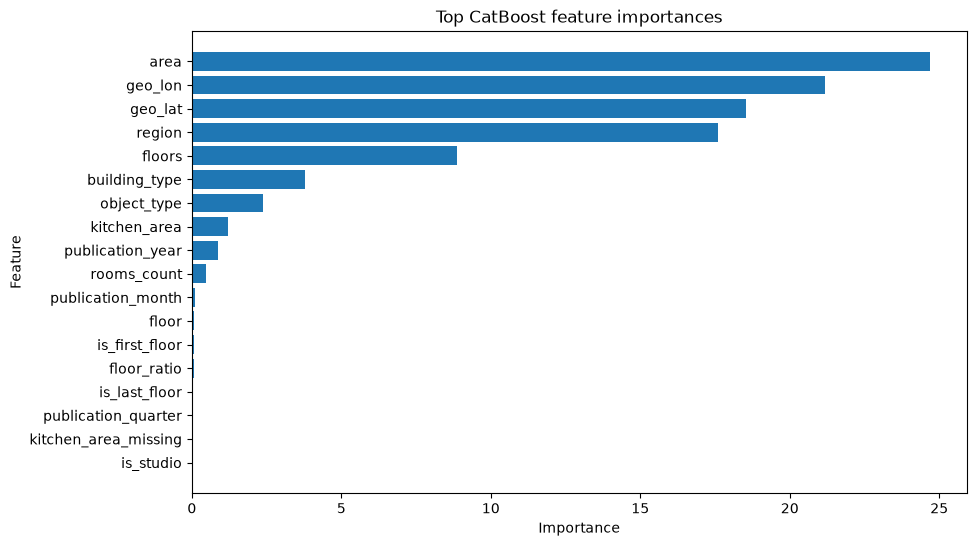

In [37]:
top_n = 20

plt.figure(figsize=(10, 6))
plt.barh(
    catboost_importance.head(top_n)["feature"][::-1],
    catboost_importance.head(top_n)["importance"][::-1],
)
plt.title("Top CatBoost feature importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
FEATURE_IMPORTANCE_PATH = FIGURES_DIR / "catboost_feature_importance.png"

plt.savefig(FEATURE_IMPORTANCE_PATH, dpi=300, bbox_inches="tight")

print("Saved figure:", FEATURE_IMPORTANCE_PATH)

## Save artifacts

In [38]:
MODEL_PATH = MODELS_DIR / f"{best_model_name}_model.joblib"
METRICS_PATH = REPORTS_DIR / "model_metrics.csv"
PREDICTIONS_PATH = REPORTS_DIR / "test_predictions.csv"
FEATURE_IMPORTANCE_PATH = REPORTS_DIR / "catboost_feature_importance.csv"

joblib.dump(best_model, MODEL_PATH)

metrics_table.to_csv(METRICS_PATH, index=False)

advisor_results.to_csv(PREDICTIONS_PATH, index=False)

catboost_importance.to_csv(FEATURE_IMPORTANCE_PATH, index=False)

print("Saved model:", MODEL_PATH)
print("Saved metrics:", METRICS_PATH)
print("Saved predictions:", PREDICTIONS_PATH)
print("Saved feature importance:", FEATURE_IMPORTANCE_PATH)

Saved model: c:\Users\mikri\OneDrive\Desktop\real-estate-price-advisor\models\catboost_model.joblib
Saved metrics: c:\Users\mikri\OneDrive\Desktop\real-estate-price-advisor\reports\model_metrics.csv
Saved predictions: c:\Users\mikri\OneDrive\Desktop\real-estate-price-advisor\reports\test_predictions.csv
Saved feature importance: c:\Users\mikri\OneDrive\Desktop\real-estate-price-advisor\reports\catboost_feature_importance.csv


## Save JSON metadata

In [39]:
metadata = {
    "project": "Real Estate Price Advisor",
    "split_type": split_type,
    "target": target,
    "target_transformation": "log1p(price)",
    "best_model": best_model_name,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "excluded_features": [
        "price",
        "log_price",
        "price_per_m2",
        "date",
        "time",
        "published_at",
    ],
    "metrics": metrics_table.to_dict(orient="records"),
    "advisor_threshold_percent": ADVISOR_THRESHOLD,
}

METADATA_PATH = REPORTS_DIR / "model_metadata.json"

with open(METADATA_PATH, "w", encoding="utf-8") as file:
    json.dump(metadata, file, ensure_ascii=False, indent=2)

print("Saved metadata:", METADATA_PATH)

Saved metadata: c:\Users\mikri\OneDrive\Desktop\real-estate-price-advisor\reports\model_metadata.json


## Final output

In [40]:
print("Modeling summary")
print("----------------")
print("Best model:", best_model_name)
print("Split type:", split_type)
print()
print(metrics_table)
print()
print("Saved files:")
print("- model:", MODEL_PATH)
print("- metrics:", METRICS_PATH)
print("- predictions:", PREDICTIONS_PATH)
print("- metadata:", METADATA_PATH)

Modeling summary
----------------
Best model: catboost
Split type: time_based

          model          MAE             RMSE         R2  MAPE  MdAPE  WAPE
2      catboost 1,292,953.71     3,847,273.60       0.76 19.95  16.75 22.57
0  dummy_median 3,400,781.35     8,441,421.29      -0.14 48.06  42.27 59.37
1         ridge 4,656,774.00 1,361,065,873.82 -29,551.05 33.40  20.74 81.30

Saved files:
- model: c:\Users\mikri\OneDrive\Desktop\real-estate-price-advisor\models\catboost_model.joblib
- metrics: c:\Users\mikri\OneDrive\Desktop\real-estate-price-advisor\reports\model_metrics.csv
- predictions: c:\Users\mikri\OneDrive\Desktop\real-estate-price-advisor\reports\test_predictions.csv
- metadata: c:\Users\mikri\OneDrive\Desktop\real-estate-price-advisor\reports\model_metadata.json
